# NYC Taxi Trip Duration: Exploratory Data Analysis (EDA)

### Problem Overview
The objective is to predict the total ride duration of taxi trips in New York City using pickup/dropoff spatial coordinates, engagement timestamp, and passenger data. Because our downstream regressor is constrained to a regularized linear model (`Ridge(alpha=1)`), uncovering non-linearities, spatial boundaries, and temporal bottlenecks is critical for effective feature engineering.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../../Data/train.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")  

Dataset shape: 5000 rows, 10 columns


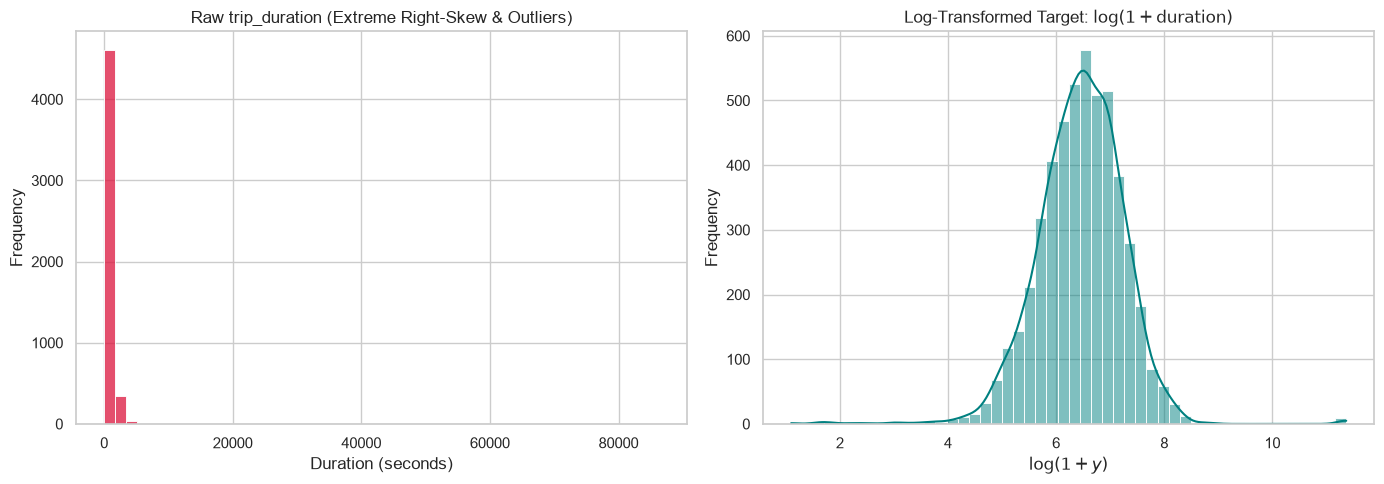

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Raw Distribution
sns.histplot(df["trip_duration"], bins=50, kde=False, ax=axes[0], color="crimson")
axes[0].set_title("Raw trip_duration (Extreme Right-Skew & Outliers)")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Frequency")

# 2. Log-Transformed Distribution
sns.histplot(np.log1p(df["trip_duration"]), bins=50, kde=True, ax=axes[1], color="teal")
axes[1].set_title(r"Log-Transformed Target: $\log(1 + \text{duration})$")
axes[1].set_xlabel(r"$\log(1 + y)$")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Target Distribution Takeaways:
1. **Severe Outliers:** The raw `trip_duration` contains anomalous trips lasting from 2 seconds up to 86,329 seconds (~24 hours). Such extreme values heavily distort Ordinary Least Squares / Ridge loss functions (MSE), causing regression coefficients to tilt drastically.
2. **Log-Transformation:** Applying $\log(1 + y)$ converts the heavily right-skewed distribution into a well-behaved, symmetric Gaussian-like distribution, aligning with linear model assumptions and stabilizing residual variance.

In [4]:
coord_stats = df[["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]].agg(["min", "max"])
coord_stats

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
min,-74.177292,40.619514,-74.183403,40.575306
max,-70.851616,43.017578,-70.851616,43.017578


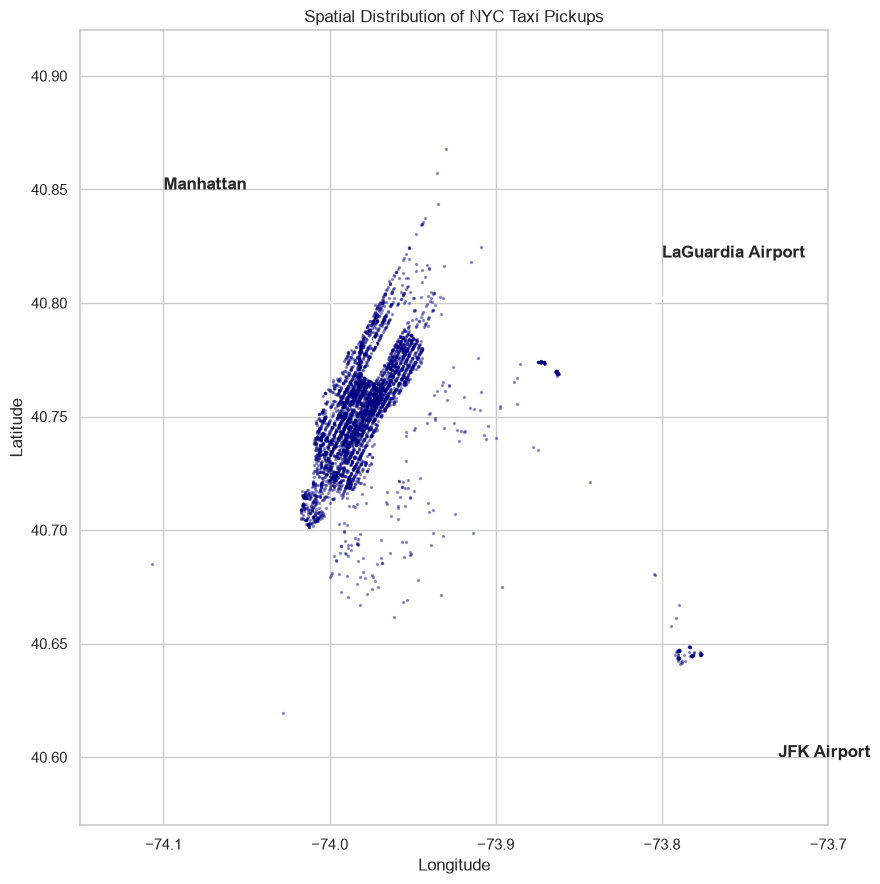

In [5]:

NYC_BOUNDS = {
    "lat_min": 40.57, "lat_max": 40.92,
    "lon_min": -74.15, "lon_max": -73.70
}

nyc_pickups = df[
    df["pickup_latitude"].between(NYC_BOUNDS["lat_min"], NYC_BOUNDS["lat_max"]) &
    df["pickup_longitude"].between(NYC_BOUNDS["lon_min"], NYC_BOUNDS["lon_max"])
]

plt.figure(figsize=(9, 9))
plt.scatter(nyc_pickups["pickup_longitude"], nyc_pickups["pickup_latitude"], s=2, alpha=0.35, c="navy")
plt.title("Spatial Distribution of NYC Taxi Pickups")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(NYC_BOUNDS["lon_min"], NYC_BOUNDS["lon_max"])
plt.ylim(NYC_BOUNDS["lat_min"], NYC_BOUNDS["lat_max"])

plt.annotate("Manhattan", xy=(-73.97, 40.78), xytext=(-74.10, 40.85),
             arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.2), fontweight="bold")
plt.annotate("JFK Airport", xy=(-73.78, 40.64), xytext=(-73.73, 40.60),
             arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.2), fontweight="bold")
plt.annotate("LaGuardia Airport", xy=(-73.87, 40.77), xytext=(-73.80, 40.82),
             arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.2), fontweight="bold")

plt.tight_layout()
plt.show()

### Coordinate & Spatial Takeaways:
1. **GPS Errors:** Coordinates extend beyond valid New York boundaries (e.g., latitude > 43.0 and longitude < -74.17), indicating faulty sensors or trips outside city service boundaries.
2. **Dense Clusters:** The vast majority of pickups occur along the Manhattan street grid, with prominent isolated clusters at JFK and LaGuardia airports. Linear models cannot infer street grids or airport hubs without explicit distance metrics and spatial transformations.

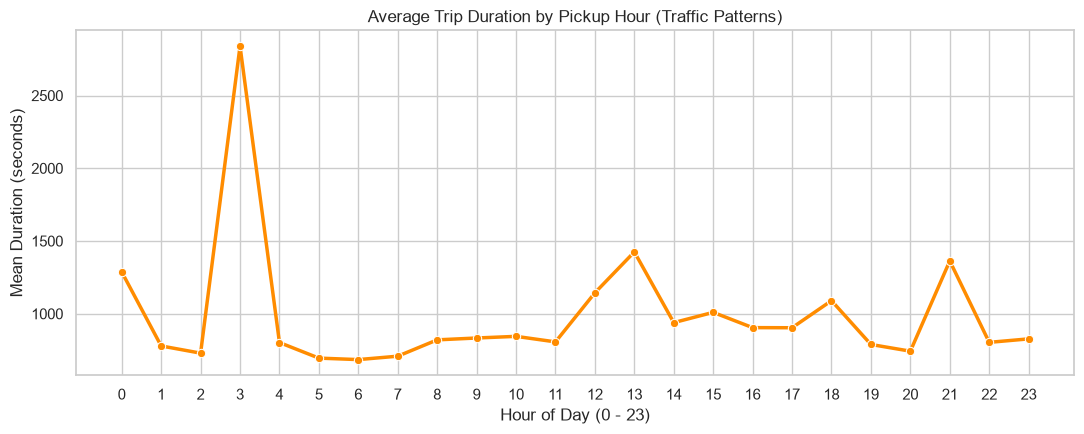

In [6]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["hour"] = df["pickup_datetime"].dt.hour
df["dayofweek"] = df["pickup_datetime"].dt.dayofweek

hourly_trend = df.groupby("hour")["trip_duration"].mean().reset_index()

plt.figure(figsize=(11, 4.5))
sns.lineplot(data=hourly_trend, x="hour", y="trip_duration", marker="o", color="darkorange", linewidth=2.5)
plt.title("Average Trip Duration by Pickup Hour (Traffic Patterns)")
plt.xlabel("Hour of Day (0 - 23)")
plt.ylabel("Mean Duration (seconds)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()